# 01 - Screening: encontrar los factores que importan

**Caso de uso.** Estamos poniendo a punto un bioproceso con **7 factores** candidatos
(temperatura, pH, agitacion, concentracion de sustrato, tiempo, inductor, oxigeno
disuelto). Un factorial completo a 2 niveles serian `2**7 = 128` corridas: demasiado
caro para una fase exploratoria.

El **principio de esparsidad de efectos** (sparsity of effects) dice que, tipicamente,
solo unos pocos factores dominan la respuesta. Un diseno de **Plackett-Burman** nos deja
estimar los 7 efectos principales con **solo 8 corridas** y decidir cuales llevar a la
siguiente etapa.

Este notebook muestra el flujo completo: construir el diseno, verificar su ortogonalidad,
simular una respuesta, estimar efectos, graficar el *half-normal plot* y de-confundir
interacciones con un *foldover*.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import doekit as ed
from doekit import plotting

rng = np.random.default_rng(7)
plt.rcParams["figure.figsize"] = (7, 4)

## 1. El diseno de screening

`plackett_burman(7)` elige la menor matriz de Hadamard con al menos 8 columnas. Para 7
factores basta el orden 8 (construccion de Sylvester), sin columnas *dummy*.

In [2]:
pb = ed.plackett_burman(7, names=["temp", "pH", "agit", "sust", "tiempo", "induct", "O2"])
print(pb)
print("\nPlackett-Burman valido:", ed.is_plackett_burman(pb))

PlackettBurman
Dimension: (8, 7)
Factors: ['temp', 'pH', 'agit', 'sust', 'tiempo', 'induct', 'O2']
Model: Model(0 ~ temp + pH + agit + sust + tiempo + induct + O2)
Design Matrix:
   temp  pH  agit  sust  tiempo  induct  O2
0     1   1     1     1       1       1   1
1    -1   1    -1     1      -1       1  -1
2     1  -1    -1     1       1      -1  -1
3    -1  -1     1     1      -1      -1   1
4     1   1     1    -1      -1      -1  -1
5    -1   1    -1    -1       1      -1   1
6     1  -1    -1    -1      -1       1   1
7    -1  -1     1    -1       1       1  -1

Plackett-Burman valido: True


## 2. Por que funciona: ortogonalidad

En un diseno ortogonal las columnas no estan correlacionadas: el efecto de cada factor se
estima **independientemente** de los demas, y todos con el mismo error estandar. Lo vemos
en el mapa de correlacion de la matriz del modelo (fuera de la diagonal ~ 0).

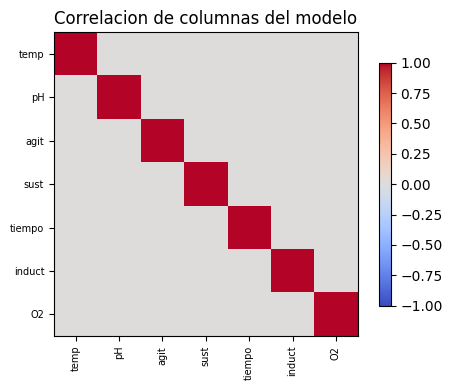

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
plotting.correlation_plot(pb, ax=ax)
plt.tight_layout(); plt.show()

## 3. Una respuesta simulada

Simulamos un experimento donde **solo 3 factores son activos** (temp, sust, O2) y el resto
son practicamente inertes. Ademas escondemos una **interaccion** temp x sust, que en un
diseno de resolucion baja quedara aliasada con las columnas del diseno: justamente lo que
el screening debe ayudarnos a sospechar.

In [4]:
coef = {"temp": 6.0, "pH": 0.2, "agit": -0.3, "sust": 4.0,
        "tiempo": 0.1, "induct": -0.25, "O2": -3.0}
X = pb.matrix
y = (50.0
     + sum(coef[c] * X[c] for c in coef)
     + 2.5 * X["temp"] * X["sust"]          # interaccion oculta
     + rng.normal(0, 0.5, pb.n_runs))
y = y.values
pd.DataFrame({**{c: X[c] for c in coef}, "y": np.round(y, 2)})

,temp,pH,agit,sust,tiempo,induct,O2,y
0,1,1,1,1,1,1,1,59.25
1,-1,1,-1,1,-1,1,-1,48.80
2,1,-1,-1,1,1,-1,-1,65.81
3,-1,-1,1,1,-1,-1,1,41.70
4,1,1,1,-1,-1,-1,-1,52.32
5,-1,1,-1,-1,1,-1,1,39.85
6,1,-1,-1,-1,-1,1,1,46.28
7,-1,-1,1,-1,1,1,-1,45.52


## 4. Efectos principales

`main_effects` ajusta un modelo de efectos principales sobre el diseno (OLS interno) y
devuelve el coeficiente de cada factor. Por ortogonalidad, estos coeficientes son los
efectos estimados.

In [5]:
effects = ed.main_effects(pb, y)
effects.sort_values(key=np.abs, ascending=False).round(3)

temp      5.973
sust      3.949
O2       -3.171
tiempo    2.666
agit     -0.244
pH        0.114
induct    0.019
Name: coefficient, dtype: float64

## 5. Distribucion de efectos y half-normal plot

Dos vistas complementarias:

- El **histograma** de las magnitudes de efecto muestra un grupo cerca de 0 (ruido) y unos
  pocos grandes (senal).
- El **half-normal plot** ordena `|efecto|` contra los cuantiles de una media-normal: los
  efectos inertes caen sobre una recta y los **activos se despegan** hacia arriba a la
  derecha.

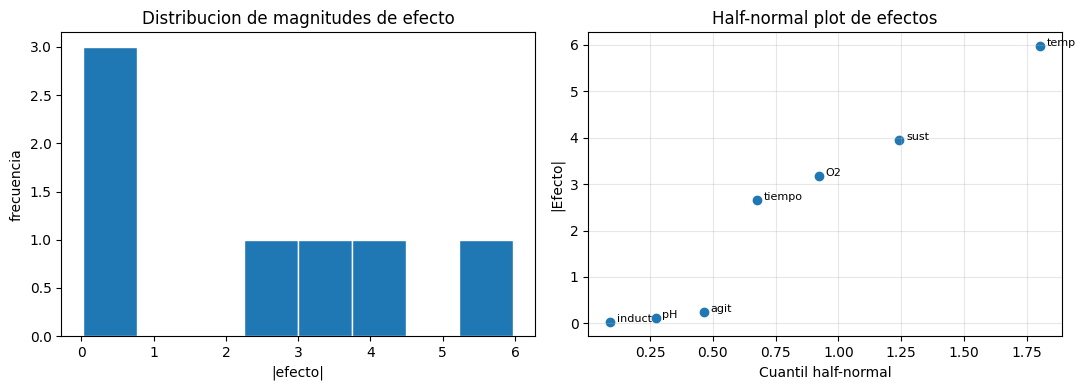

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.hist(np.abs(effects.values), bins=8, color="tab:blue", edgecolor="white")
ax1.set_xlabel("|efecto|"); ax1.set_ylabel("frecuencia")
ax1.set_title("Distribucion de magnitudes de efecto")
plotting.half_normal_plot(effects.values, effects.index, ax=ax2)
plt.tight_layout(); plt.show()

**Lectura.** `temp`, `sust` y `O2` se separan claramente del resto: son los factores
activos. Coincide con como simulamos los datos. Los demas quedan cerca de la recta = ruido.

## 6. El riesgo de aliasing y el foldover

En un Plackett-Burman de resolucion III, los efectos principales estan **confundidos con
interacciones de dos factores**. Nuestra interaccion oculta `temp x sust` puede estar
inflando o sesgando algun efecto principal. Un **foldover** (anadir el reflejo de signo del
diseno) duplica las corridas y **de-confunde** los efectos principales de las interacciones
de dos factores.

In [7]:
folded = ed.fold(pb)
print("corridas:", pb.n_runs, "->", folded.n_runs)

# reevaluamos la respuesta en el diseno plegado
Xf = folded.matrix
yf = (50.0
      + sum(coef[c] * Xf[c] for c in coef)
      + 2.5 * Xf["temp"] * Xf["sust"]
      + rng.normal(0, 0.5, folded.n_runs)).values
effects_folded = ed.main_effects(folded, yf)

comp = pd.DataFrame({"PB (8 corridas)": effects, "Foldover (16 corridas)": effects_folded})
comp.round(3)

corridas: 8 -> 16


,PB (8 corridas),Foldover (16 corridas)
temp,5.973,6.163
pH,0.114,0.083
agit,-0.244,-0.234
sust,3.949,4.057
tiempo,2.666,0.047
induct,0.019,-0.342
O2,-3.171,-3.049


Los efectos principales se mantienen estables tras el foldover: son reales y no
artefactos de una interaccion aliasada. Con esto cerramos la fase de screening con una
**lista corta** de factores (`temp`, `sust`, `O2`) para optimizar en el notebook 02.

## Evaluación del diseño (nuevo en doekit)

Antes de confiar en el screening, `doekit` certifica su calidad: potencia para
detectar los efectos y estructura de alias.

Design evaluation  (8 runs, 8 params, dof=0)
--------------------------------------------------------
  D-efficiency :  100.0 %
  A-efficiency :  100.0 %
  G-efficiency :  100.0 %
  SPV (scaled prediction variance) over region:
      min=1.188  mean=3.331  max=6.587
  Power (effect/sigma anticipated):
  Max VIF: 1.00


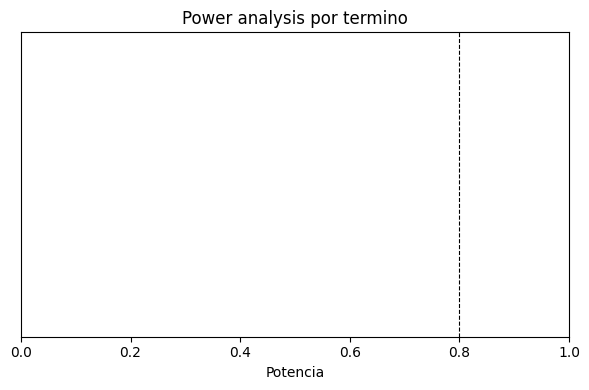

In [8]:
import doekit as ed
from doekit import plotting
import matplotlib.pyplot as plt

pb_eval = ed.plackett_burman(7)
rep = ed.evaluate(pb_eval, model=ed.Model.main_effects(pb_eval.factor_names),
                  effect_size=2.0, sigma=1.0, seed=0)
print(rep.summary())

fig, ax = plt.subplots(figsize=(6,4))
plotting.power_plot(rep.power, ax=ax); plt.tight_layout(); plt.show()


## Reporte del experimento (guía semántica)

El cierre de todo DoE es el **reporte**: qué se hizo, qué tan bueno fue el diseño, qué observar y qué concluir. Generamos el HTML autocontenido y mostramos su **guía semántica inline** para validar que coincide con lo que el análisis de arriba mostró.

In [9]:
m_scr = ed.Model.main_effects(pb.metadata["factors"])
rep = ed.report(pb, response=y, model=m_scr, output_dir="reports",
                filename="reporte_01_screening.html", title="Screening de factores")
guide = ed.report_summary(pb, response=y, model=m_scr)

print("METODOLOGIA\n ", guide["methodology"], "\n")
print("RESUMEN EJECUTIVO")
for b in guide["executive_summary"]:
    print("  -", b)
print("\nRECOMENDACIONES (que accionar / que observar)")
for r in guide["recommendations"]:
    print("  ->", r)
an = guide["anomalies"]
if an is not None and len(an):
    print("\nVALORES ANOMALOS (corridas a revisar):")
    print(an.to_string(index=False))
print("\nReporte HTML autocontenido en:", rep)


METODOLOGIA
  Diseno de screening de Plackett-Burman: estima efectos principales de forma ortogonal en el minimo de corridas. 

RESUMEN EJECUTIVO
  - Calidad del diseno: D-eficiencia 100% (excelente), G-eficiencia 100%.
  - Ajuste saturado (dof=0): R2=1.000 por construccion; sin test de significancia: usa el half-normal plot.

RECOMENDACIONES (que accionar / que observar)
  -> Diseno saturado para el modelo (sin grados de libertad para test de significancia): identifica los efectos activos con el half-normal plot o las medias. Los factores que se despegan de la recta son candidatos a una fase de superficie de respuesta (box_behnken / central_composite).

Reporte HTML autocontenido en: reports\reporte_01_screening.html


## ¿Fue el diseño apropiado? (asesor de doekit)

Cierre: el asesor infiere el escenario de lo ejecutado y recomienda el método más apropiado, comparándolo con lo que hicimos — una recomendación coherente con el experimento. El 'mejor' es un trade-off (corridas vs precisión vs predicción); por eso se muestran las alternativas.

In [10]:
rec = guide["recommendation"]
if rec:
    print("DISENO EJECUTADO vs RECOMENDADO PARA ESTE CASO")
    print(" ", rec["note"])
    print()
    print(rec["table"].to_string(index=False))
else:
    print("(sin recomendacion: el diseno no tiene modelo asociado)")


DISENO EJECUTADO vs RECOMENDADO PARA ESTE CASO
  El diseno ejecutado (Plackett-Burman) coincide con el recomendado para este caso: buena eleccion.

              metodo  corridas  D_eff  G_eff  SPV_medio  en_presupuesto  soporta_modelo
     Plackett-Burman         8  100.0  100.0       3.32            True            True
Definitive Screening        17   84.4  100.0       3.82           False            True
